In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/odroid1_firefox_carbonyl14.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/odroid2_firefox_carbonyl14.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/odroid3_firefox_carbonyl14.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/odroid4_firefox_carbonyl14.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi-4a_chrome_carbonyl14.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi-8a_chrome_carbonyl14.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi_8b_carbonyl_onscreen_VEC14.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi_8c_carbonyl_onscreen_VEC14.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi-8d_chrome_carbonyl14.csv")

In [4]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)
np.random.seed(29)

In [5]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Feature 11,Feature 12,Feature 13
0,odroid4,88.3,88.0,85.7,84.3,84.0,84.2,84.3,84.0,84.6,85.0,84.6,84.6,84.0,84.1
1,odroid3,86.6,89.1,83.2,82.0,81.7,81.5,81.8,81.8,81.7,81.6,81.5,81.2,81.6,81.5
2,odroid2,94.0,88.4,87.5,86.0,85.0,86.4,87.4,84.8,85.6,85.6,88.0,85.5,85.9,84.6
3,odroid2,88.5,87.1,85.8,84.7,84.4,84.8,84.1,84.4,84.5,84.3,84.4,84.4,84.4,84.3
4,odroid1,88.8,85.9,85.9,84.6,84.0,84.0,84.1,84.6,84.1,84.4,84.1,84.3,84.3,84.4


In [6]:
len(df)

9000

In [7]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 9000, 1000):
    train_data = df.head(i)
    test_data = df.tail(1000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels\ag-20250203_024050"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       48.42 GB / 63.72 GB (76.0%)
Disk Space Avail:   1284.93 GB / 1906.98 GB (67.4%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\AutogluonModels\ag-20250203_024050"
Train Data Rows:    1000
Train Data Columns: 14
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid4', 'odroid3', 'odroid2', 'odroid1', 'rpi-4a', 'rpi-8a', 'rpi_8c', 'rpi-8d', 'rpi_8b']
	If 'multiclass' is not the correct problem_type, please manually specify t

In [8]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.674483,0.673,0.672340
1,2000,0.651745,0.652,0.650794
2,3000,0.675706,0.671,0.671514
3,4000,0.686051,0.681,0.681476
4,5000,0.682260,0.680,0.680484
5,6000,0.681260,0.682,0.679619
6,7000,0.685536,0.685,0.682721
7,8000,0.695272,0.694,0.692491


<Axes: xlabel='data_amount', ylabel='value'>

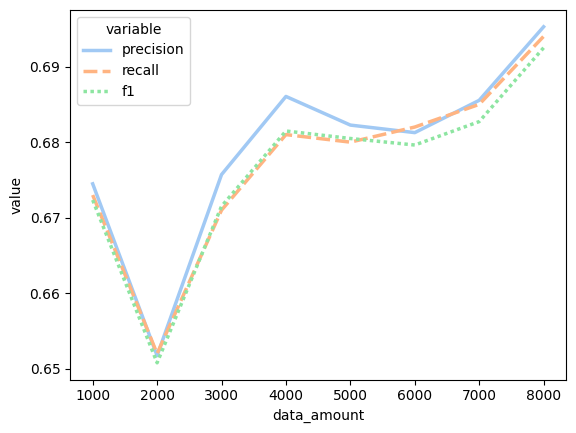

In [9]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [10]:
best_model

{'LightGBMXT': 2,
 'WeightedEnsemble_L2': 3,
 'ExtraTreesGini': 4,
 'RandomForestEntr': 4,
 'RandomForestGini': 6,
 'XGBoost': 1,
 'ExtraTreesEntr': 3,
 'LightGBM': 1}

([<matplotlib.patches.Wedge at 0x1f0480c6e50>,
 [Text(1.062518406696673, 0.28470095790278555, 'LightGBMXT'),
  Text(0.6696375582917576, 0.872688684769691, 'WeightedEnsemble_L2'),
  Text(-0.2847009827728236, 1.0625184000327659, 'ExtraTreesGini'),
  Text(-1.062518426688391, 0.2847008832926707, 'RandomForestEntr'),
  Text(-0.5499999256737775, -0.9526279870751434, 'RandomForestGini'),
  Text(0.4209518588576976, -1.0162674512766063, 'XGBoost'),
  Text(0.8726887317916832, -0.6696374970114979, 'ExtraTreesEntr'),
  Text(1.090589360393888, -0.14357871358822688, 'LightGBM')],
 [Text(0.5795554945618215, 0.15529143158333755, '8%'),
  Text(0.3652568499773223, 0.47601200987437686, '12%'),
  Text(-0.15529144514881282, 0.5795554909269631, '17%'),
  Text(-0.5795555054663949, 0.15529139088691127, '17%'),
  Text(-0.29999995945842406, -0.5196152656773508, '25%'),
  Text(0.22961010483147137, -0.5543277006963306, '4%'),
  Text(0.4760120355227362, -0.3652568165517261, '12%'),
  Text(0.5948669238512116, -0.07

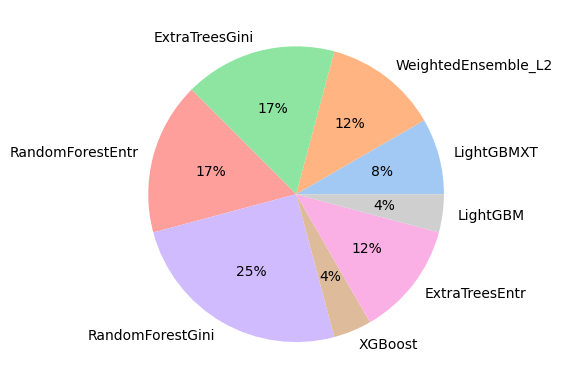

In [11]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [12]:
best_features

{'Feature 1': 8,
 'Feature 0': 7,
 'Feature 3': 6,
 'Feature 8': 1,
 'Feature 9': 1,
 'Feature 11': 1}

([<matplotlib.patches.Wedge at 0x1f0484c4f10>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Feature 1'),
  Text(-1.0905893519921306, 0.14357877740594205, 'Feature 0'),
  Text(-2.0206672185931328e-16, -1.1, 'Feature 3'),
  Text(0.8726886769326917, -0.6696375685051342, 'Feature 8'),
  Text(1.016267490688959, -0.42095176370787046, 'Feature 9'),
  Text(1.0905893503117785, -0.14357879016948558, 'Feature 11')],
 [Text(0.2999999837833699, 0.5196152516333385, '33%'),
  Text(-0.5948669192684347, 0.07831569676687748, '29%'),
  Text(-1.1021821192326178e-16, -0.6, '25%'),
  Text(0.47601200559964996, -0.365256855548255, '4%'),
  Text(0.5543277221939775, -0.22961005293156567, '4%'),
  Text(0.5948669183518791, -0.0783157037288103, '4%')])

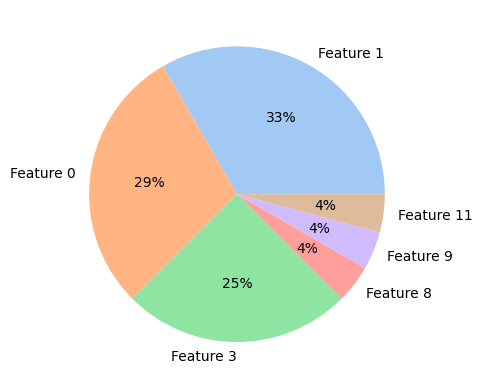

In [13]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [14]:
results

{'precision': 0.6952717545990167,
 'recall': 0.694,
 'f1-score': 0.6924907774155014,
 'support': 1000.0}